# Benchmark: Simpson vs Gauss-Legendre multipole projection

Compares two quadrature strategies for the multipole integral

$$P_\ell(k) = (2\ell+1)\int_0^1 P(k,\mu)\,\mathcal{L}_\ell(\mu)\,d\mu$$

| Method | Description | $\mu$-points | $P(k,\mu)$ evals per bin |
|--------|-------------|-------------|-------------------------|
| **Simpson** (legacy) | `quadax.simpson` over `num=256` uniform points | 256 | 3 (one per $\ell$) |
| **Gauss-Legendre** (new) | Pretabulated GL weights, single matmul | 16 | 1 |

We benchmark:
1. **Correctness**: theory vector and Jacobian agreement
2. **Performance**: JIT compilation time, per-evaluation wall-clock time
3. **Memory**: peak JAX device memory during Jacobian computation

Setup uses the PFS 7-bin $\Lambda$CDM + AP configuration (100 parameters).

### Expected accuracy

For **polynomial** integrands, GL(16) is exact for degree $\leq 31$ and
matches Simpson(256) to $\sim10^{-11}$.  However, the 1-loop integrand
with IR resummation contains **non-polynomial** terms (the BAO damping
factor $e^{-k^2 \Sigma^2(\mu)}$), so the agreement between the two
methods is limited to $\sim10^{-5}$–$10^{-7}$ depending on multipole
order.  This is far below statistical uncertainties ($\sim10^{-2}$) and
the dominant error comes from Simpson's $O(h^4)$ rule, not GL.

## Setup

In [1]:
import os
import time
import gc

import numpy as np

import jax
jax.config.update("jax_enable_x64", True)
import jax.numpy as jnp

from ps_1loop_jax import background as bg

from jaxptpolypol.model import CosmoEmulator, PS1LoopModel
from jaxptpolypol.params import (CosmoParams, SurveyParams,
                                  pack_multibin_params)
from jaxptpolypol.covariance import gaussian_covariance
from jaxptpolypol.inference import fisher_matrix, marginalize_fisher
from jaxptpolypol.theory import make_pk_ell_fn, compute_fiducial_distances

print(f"JAX version: {jax.__version__}")
print(f"Backend: {jax.default_backend()}")
print(f"Devices: {jax.devices()}")

JAX version: 0.6.2
Backend: cpu
Devices: [CpuDevice(id=0)]


In [2]:
model_path = '/Users/nguyenmn/cosmopower-jax-for-pfs/cosmology/jense2024/jense_2023_camb_lcdm/networks/jense_2023_camb_lcdm_Pk_lin.npz'

pklin_emulator = CosmoEmulator(probe='custom_log', emulator_path=model_path)
ps1loop_model = PS1LoopModel(do_irres=True)
print(f"Emulator modes: {len(pklin_emulator.modes)} k-points")

Tried to load pickle file from pre-trained model, but failed.
This usually means that you have TF>=2.14, or that you are loading a model that was trained on PCA but loaded with the log (or viceversa), or that you are loading a non-standard model from the cosmopower-organization repo.
Falling back to the dictionary, in case this also fails or does not output the right shape make sure you ran the `convert_tf214.py` script, and that a `.npz` file exists among the trained models, and that you ran `pip install .`. Also make sure that you are asking for the right probe between `custom_log` and `custom_pca`.
Emulator modes: 1000 k-points


In [3]:
cosmo_dict = {
    'ombh2':    0.02242,
    'omch2':    0.11933,
    'logA':     3.047,
    'ns':       0.9665,
    'h':        0.6766,
    'z':        0.7,
    'A_b':      3.13,
    'eta_b':    0.603,
    'logT_AGN': 7.8,
}
cosmo = CosmoParams(cosmo_dict)

In [4]:
# PFS 7-bin survey specifications
z_bins   = (0.7,  0.9,  1.1,  1.3,  1.5,  1.8,  2.2)
V_bins   = tuple(v * 1000.**3 for v in (0.59, 0.79, 0.96, 1.09, 1.19, 2.58, 2.71))
knl_bins = (0.52, 0.65, 0.82, 1.02, 1.29, 1.82, 2.88)
n_dens   = (3.06e-4, 9.61e-4, 9.75e-4, 6.54e-4, 3.40e-4, 2.02e-4, 3.51e-4)
n_zbins  = len(z_bins)

def b1z(z): return 0.9 + 0.4*z
def b2z(z): return -0.704 - 0.208*z + 0.183*z**2 - 0.00771*z**3
def bG2z(z): return -(2./7.)*(b1z(z) - 1.)
def bGamma3z(z): return (23./42.)*(b1z(z) - 1.)
def Dplusz(z):
    return float(bg.growth_factor(
        cosmo_dict['ombh2'], cosmo_dict['omch2'], cosmo_dict['h'], z, mnu=0.06))
def c0z(z): return 25.*Dplusz(z)**2
def c2z(z): return 25.*Dplusz(z)**2
def c4z(z): return Dplusz(z)**2

surveys = []
for z, knl, nd in zip(z_bins, knl_bins, n_dens):
    surveys.append(SurveyParams({
        'bias':  {'b1': b1z(z), 'b2': b2z(z), 'bG2': bG2z(z), 'bGamma3': bGamma3z(z)},
        'ctr':   {'c0': c0z(z), 'c2': c2z(z), 'c4': c4z(z), 'cfog': knl**(-4)},
        'stoch': {'P_shot': 1.0, 'a0': 0., 'a2': 0.},
        'k_nl': knl, 'ndens': nd,
    }))

packed_params = pack_multibin_params(cosmo, surveys)
n_cosmo  = sum(cosmo.param_sizes)
n_survey = len(surveys[0].param_keys)
print(f"Total params: {packed_params.shape[0]}  (cosmo {n_cosmo} + {n_zbins} x survey {n_survey})")

Total params: 100  (cosmo 9 + 7 x survey 13)


In [5]:
ells = (0, 2, 4)
n_ell = len(ells)
N_K = 30
k = jnp.linspace(5e-3, 0.25, N_K)
n_k = len(k)

Hz_fid, DAz_fid = compute_fiducial_distances(cosmo, z_bins)

print(f"k grid: {N_K} points in [{float(k[0]):.4f}, {float(k[-1]):.3f}] h/Mpc")
print(f"Theory vector: {n_zbins} bins x {n_ell} ells x {n_k} k = {n_zbins * n_ell * n_k} elements")

k grid: 30 points in [0.0050, 0.250] h/Mpc
Theory vector: 7 bins x 3 ells x 30 k = 630 elements


## Build theory wrappers

Two wrappers with identical physics, differing only in the quadrature method.

In [6]:
common_kwargs = dict(
    ells=ells,
    pklin_emulator=pklin_emulator,
    ps1loop_model=ps1loop_model,
    cosmo_keys=cosmo.param_keys,
    cosmo_sizes=cosmo.param_sizes,
    survey_keys=surveys[0].param_keys,
    ap=True,
    z_bins=z_bins,
    Hz_fid=Hz_fid,
    DAz_fid=DAz_fid,
)

# Legacy: Simpson's rule with 256 mu-points
pk_fn_simpson = make_pk_ell_fn(**common_kwargs, n_gl=None, num=256)

# New: Gauss-Legendre with 16 nodes
pk_fn_gl = make_pk_ell_fn(**common_kwargs, n_gl=16)

print("Wrappers built.")
print(f"  Simpson: num=256, n_gl=None")
print(f"  GL:      num=N/A, n_gl=16")

Wrappers built.
  Simpson: num=256, n_gl=None
  GL:      num=N/A, n_gl=16


---
## A. Correctness comparison

Verify that GL(16) and Simpson(256) produce numerically equivalent results.

### A1. Theory vectors

In [7]:
# Evaluate both (includes JIT compilation)
jitted_simpson = jax.jit(pk_fn_simpson)
jitted_gl      = jax.jit(pk_fn_gl)

pk_simpson = jitted_simpson(packed_params, k=k).block_until_ready()
pk_gl      = jitted_gl(packed_params, k=k).block_until_ready()

# Absolute and relative differences
abs_diff = jnp.abs(pk_simpson - pk_gl)
rel_diff = abs_diff / jnp.abs(pk_simpson)

print("Theory vector comparison (Simpson vs GL):")
print(f"  Max absolute difference : {float(abs_diff.max()):.3e}")
print(f"  Max relative difference : {float(rel_diff.max()):.3e}")
print(f"  Mean relative difference: {float(rel_diff.mean()):.3e}")
print(f"  RMS  relative difference: {float(jnp.sqrt(jnp.mean(rel_diff**2))):.3e}")

Theory vector comparison (Simpson vs GL):
  Max absolute difference : 7.115e-02
  Max relative difference : 4.634e-05
  Mean relative difference: 1.386e-05
  RMS  relative difference: 2.291e-05


Text(0.5, 1.01, 'Simpson(256) vs Gauss-Legendre(16) — per bin')

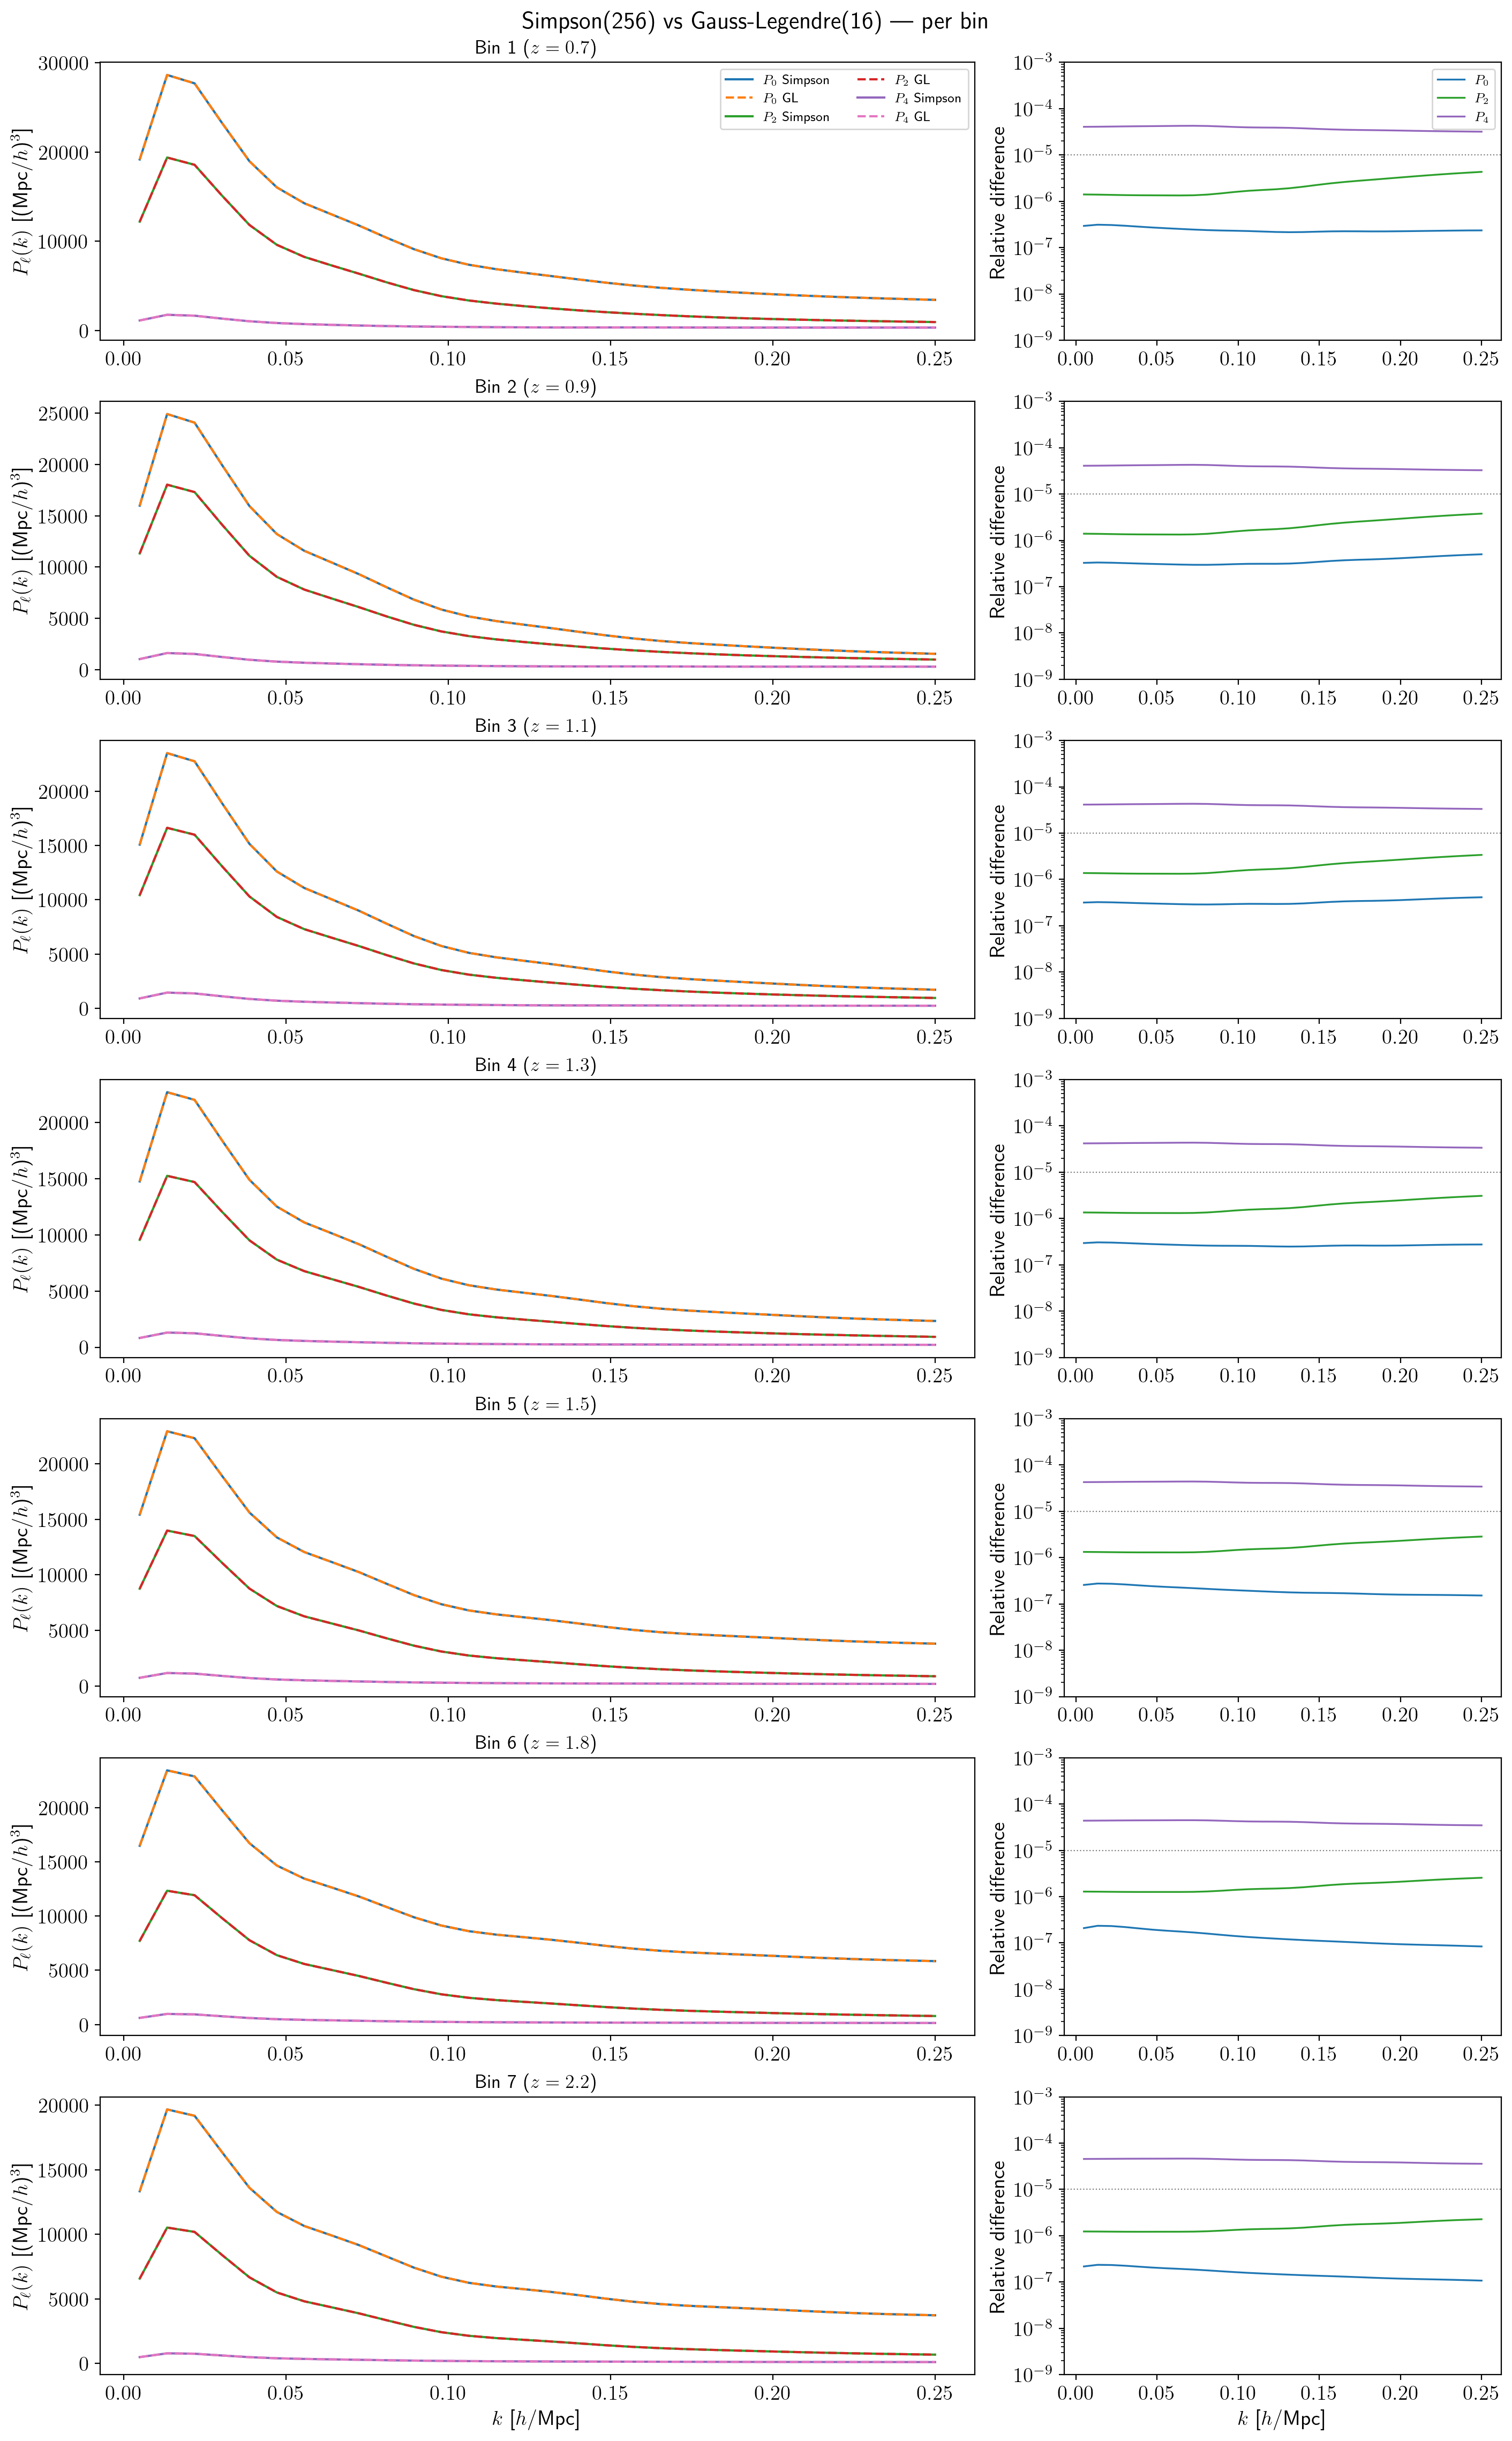

In [8]:
import matplotlib
%matplotlib inline
%config InlineBackend.figure_format = 'retina'
import matplotlib.pyplot as plt
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "sans-serif",
    "font.sans-serif": "Computer Modern",
    "font.size": 14})

pk_s = pk_simpson.reshape(n_zbins, n_ell, n_k)
pk_g = pk_gl.reshape(n_zbins, n_ell, n_k)
ell_labels = [r'$P_0$', r'$P_2$', r'$P_4$']

# Simpson in solid cool colors, GL in dashed warm colors
colors_simp = ['#1f77b4', '#2ca02c', '#9467bd']  # blue, green, purple
colors_gl   = ['#ff7f0e', '#d62728', '#e377c2']  # orange, red, pink

fig, axes = plt.subplots(n_zbins, 2, figsize=(14, 3.2 * n_zbins),
                          gridspec_kw={'width_ratios': [2, 1]},
                          constrained_layout=True)

for b in range(n_zbins):
    # Left panel: P_ell(k) for Simpson and GL
    ax_pk = axes[b, 0]
    for l_idx, label in enumerate(ell_labels):
        ax_pk.plot(k, pk_s[b, l_idx], '-',  color=colors_simp[l_idx], lw=1.5,
                   label=f'{label} Simpson')
        ax_pk.plot(k, pk_g[b, l_idx], '--', color=colors_gl[l_idx], lw=1.5,
                   label=f'{label} GL')
    ax_pk.set_ylabel(r'$P_\ell(k)$ [(Mpc/$h$)$^3$]')
    ax_pk.set_title(f'Bin {b+1}  ($z = {z_bins[b]}$)', fontsize=13)
    if b == 0:
        ax_pk.legend(fontsize=9, ncol=2, loc='upper right')
    if b == n_zbins - 1:
        ax_pk.set_xlabel(r'$k$ [$h$/Mpc]')

    # Right panel: relative difference per multipole
    ax_rd = axes[b, 1]
    for l_idx, label in enumerate(ell_labels):
        rd = jnp.abs(pk_s[b, l_idx] - pk_g[b, l_idx]) / jnp.abs(pk_s[b, l_idx])
        ax_rd.semilogy(k, rd, '-', color=colors_simp[l_idx], lw=1.2, label=label)
    ax_rd.axhline(1e-5, color='gray', ls=':', lw=0.8)
    ax_rd.set_ylim(1e-9, 1e-3)
    ax_rd.set_ylabel('Relative difference')
    if b == 0:
        ax_rd.legend(fontsize=9)
    if b == n_zbins - 1:
        ax_rd.set_xlabel(r'$k$ [$h$/Mpc]')

fig.suptitle('Simpson(256) vs Gauss-Legendre(16) — per bin',
             fontsize=16, y=1.01)

### A2. Jacobians and Fisher matrices

In [9]:
# Jacobians via forward-mode AD
jac_simpson = jax.jacfwd(jitted_simpson, argnums=0)(packed_params, k=k)
jac_gl      = jax.jacfwd(jitted_gl, argnums=0)(packed_params, k=k)

jac_abs_diff = jnp.abs(jac_simpson - jac_gl)
jac_rel_diff = jac_abs_diff / (jnp.abs(jac_simpson) + 1e-30)

print("Jacobian comparison:")
print(f"  Shape: {jac_simpson.shape}")
print(f"  Max absolute difference : {float(jac_abs_diff.max()):.3e}")
print(f"  Max relative difference : {float(jac_rel_diff.max()):.3e}")
print(f"  Mean relative difference: {float(jac_rel_diff.mean()):.3e}")

Jacobian comparison:
  Shape: (630, 100)
  Max absolute difference : 5.378e+03
  Max relative difference : 5.378e+33
  Mean relative difference: 6.697e+29


In [10]:
# Block-diagonal covariance (same for both methods)
from jax.scipy.linalg import block_diag, inv

pk_all = pk_gl.reshape(n_zbins, n_ell, n_k)
P_shot = 1.0
dk = k[1] - k[0]
cov_blocks = []
for b in range(n_zbins):
    P0 = pk_all[b, 0] + P_shot / n_dens[b]
    P2, P4 = pk_all[b, 1], pk_all[b, 2]
    cov_blocks.append(gaussian_covariance(V_bins[b], k, dk, P0, P2, P4))
cov = block_diag(*cov_blocks)

# Fisher matrices
F_simpson = fisher_matrix(cov, jac_simpson)
F_gl      = fisher_matrix(cov, jac_gl)

F_diff = jnp.abs(F_simpson - F_gl)
F_rel  = F_diff / (jnp.abs(F_simpson) + 1e-30)

print("Fisher matrix comparison:")
print(f"  Shape: {F_simpson.shape}")
print(f"  Max absolute difference : {float(F_diff.max()):.3e}")
print(f"  Max relative difference : {float(F_rel.max()):.3e}")
print(f"  Frobenius norm ratio    : {float(jnp.linalg.norm(F_diff) / jnp.linalg.norm(F_simpson)):.3e}")

Fisher matrix comparison:
  Shape: (100, 100)
  Max absolute difference : 1.413e+04
  Max relative difference : 1.413e+34
  Frobenius norm ratio    : 1.456e-06


In [11]:
# Compare 1-sigma constraints from the two Fisher matrices
from jaxptpolypol.inference import fixed_and_varied_indices

fixed_cosmo_idx = [5, 6, 7, 8]      # z, A_b, eta_b, logT_AGN
fixed_survey_offsets = [11, 12]       # k_nl, ndens
fixed_idx, varied_idx = fixed_and_varied_indices(
    n_cosmo, n_survey, n_zbins, fixed_cosmo_idx, fixed_survey_offsets)

F_s_var = marginalize_fisher(F_simpson, varied_idx)
F_g_var = marginalize_fisher(F_gl, varied_idx)

sigma_s = jnp.sqrt(jnp.diag(inv(F_s_var)))
sigma_g = jnp.sqrt(jnp.diag(inv(F_g_var)))

cosmo_names = [r'$\omega_b$', r'$\omega_c$', r'$\log A$', r'$n_s$', r'$h$']
cosmo_in_varied = [varied_idx.index(i) for i in range(5)]

print(f"{'Parameter':>12s}  {'Simpson':>10s}  {'GL':>10s}  {'Ratio':>8s}")
print("-" * 48)
for name, ci in zip(cosmo_names, cosmo_in_varied):
    ss = float(sigma_s[ci])
    sg = float(sigma_g[ci])
    print(f"{name:>12s}  {ss:10.4g}  {sg:10.4g}  {sg/ss:8.6f}")

   Parameter     Simpson          GL     Ratio
------------------------------------------------
  $\omega_b$    0.003989     0.00399  1.000222
  $\omega_c$    0.007859    0.007778  0.989764
    $\log A$      0.1094      0.1036  0.946865
       $n_s$     0.02363     0.02306  0.975804
         $h$      0.0206     0.02031  0.986317


---
## B. Performance comparison

We measure:
1. **JIT compilation time** (first call)
2. **Per-evaluation time** (subsequent calls, averaged over repeats)
3. **Jacobian computation time** (forward-mode AD)

In [12]:
def bench_forward(fn, params, k, n_warmup=3, n_repeat=20):
    """Benchmark a JIT-compiled forward evaluation.
    
    Returns (compile_time_s, avg_exec_time_s).
    """
    jitted = jax.jit(fn)
    
    # Compilation pass
    t0 = time.perf_counter()
    out = jitted(params, k=k)
    jax.block_until_ready(out)
    compile_time = time.perf_counter() - t0
    
    # Warmup (ensure caches are hot)
    for _ in range(n_warmup):
        out = jitted(params, k=k)
        jax.block_until_ready(out)
    
    # Timed runs
    times = []
    for _ in range(n_repeat):
        t0 = time.perf_counter()
        out = jitted(params, k=k)
        jax.block_until_ready(out)
        times.append(time.perf_counter() - t0)
    
    return compile_time, np.mean(times), np.std(times)


def bench_jacobian(fn, params, k, n_warmup=2, n_repeat=10):
    """Benchmark Jacobian computation via jacfwd.
    
    Returns (compile_time_s, avg_exec_time_s).
    """
    jitted = jax.jit(fn)
    jac_fn = jax.jacfwd(jitted, argnums=0)
    
    # Compilation pass
    t0 = time.perf_counter()
    jac = jac_fn(params, k=k)
    jax.block_until_ready(jac)
    compile_time = time.perf_counter() - t0
    
    # Warmup
    for _ in range(n_warmup):
        jac = jac_fn(params, k=k)
        jax.block_until_ready(jac)
    
    # Timed runs
    times = []
    for _ in range(n_repeat):
        t0 = time.perf_counter()
        jac = jac_fn(params, k=k)
        jax.block_until_ready(jac)
        times.append(time.perf_counter() - t0)
    
    return compile_time, np.mean(times), np.std(times)

print("Benchmark helpers defined.")

Benchmark helpers defined.


### B1. Forward model evaluation

In [13]:
# Build fresh wrappers to get clean compilation times
pk_fn_simpson_fresh = make_pk_ell_fn(**common_kwargs, n_gl=None, num=256)
pk_fn_gl_fresh      = make_pk_ell_fn(**common_kwargs, n_gl=16)

gc.collect()
print("Benchmarking Simpson forward model...")
fwd_s_compile, fwd_s_avg, fwd_s_std = bench_forward(pk_fn_simpson_fresh, packed_params, k)
print(f"  Compile: {fwd_s_compile:.2f}s  |  Exec: {fwd_s_avg*1e3:.2f} +/- {fwd_s_std*1e3:.2f} ms")

gc.collect()
print("Benchmarking GL forward model...")
fwd_g_compile, fwd_g_avg, fwd_g_std = bench_forward(pk_fn_gl_fresh, packed_params, k)
print(f"  Compile: {fwd_g_compile:.2f}s  |  Exec: {fwd_g_avg*1e3:.2f} +/- {fwd_g_std*1e3:.2f} ms")

print(f"\nForward model speedup:")
print(f"  Compilation: {fwd_s_compile / fwd_g_compile:.1f}x faster")
print(f"  Execution:   {fwd_s_avg / fwd_g_avg:.1f}x faster")

Benchmarking Simpson forward model...
  Compile: 28.82s  |  Exec: 438.70 +/- 51.01 ms
Benchmarking GL forward model...
  Compile: 13.39s  |  Exec: 332.33 +/- 6.89 ms

Forward model speedup:
  Compilation: 2.2x faster
  Execution:   1.3x faster


### B2. Jacobian computation (forward-mode AD)

In [14]:
pk_fn_simpson_fresh2 = make_pk_ell_fn(**common_kwargs, n_gl=None, num=256)
pk_fn_gl_fresh2      = make_pk_ell_fn(**common_kwargs, n_gl=16)

gc.collect()
print("Benchmarking Simpson Jacobian...")
jac_s_compile, jac_s_avg, jac_s_std = bench_jacobian(pk_fn_simpson_fresh2, packed_params, k)
print(f"  Compile: {jac_s_compile:.2f}s  |  Exec: {jac_s_avg*1e3:.2f} +/- {jac_s_std*1e3:.2f} ms")

gc.collect()
print("Benchmarking GL Jacobian...")
jac_g_compile, jac_g_avg, jac_g_std = bench_jacobian(pk_fn_gl_fresh2, packed_params, k)
print(f"  Compile: {jac_g_compile:.2f}s  |  Exec: {jac_g_avg*1e3:.2f} +/- {jac_g_std*1e3:.2f} ms")

print(f"\nJacobian speedup:")
print(f"  Compilation: {jac_s_compile / jac_g_compile:.1f}x faster")
print(f"  Execution:   {jac_s_avg / jac_g_avg:.1f}x faster")

Benchmarking Simpson Jacobian...
  Compile: 126.45s  |  Exec: 55070.62 +/- 2792.64 ms
Benchmarking GL Jacobian...
  Compile: 93.39s  |  Exec: 46658.24 +/- 3591.29 ms

Jacobian speedup:
  Compilation: 1.4x faster
  Execution:   1.2x faster


### B3. Memory usage

Track JAX backend memory during Jacobian computation.  On CPU backends
JAX does not always expose fine-grained memory stats, so this section
uses `tracemalloc` as a fallback.

In [15]:
import tracemalloc

def measure_peak_memory(fn, params, k):
    """Measure peak memory during a Jacobian computation."""
    jitted = jax.jit(fn)
    # Ensure compiled first
    out = jitted(params, k=k)
    jax.block_until_ready(out)
    
    jac_fn = jax.jacfwd(jitted, argnums=0)
    # Compile the Jacobian
    jac = jac_fn(params, k=k)
    jax.block_until_ready(jac)
    
    gc.collect()
    
    # Now measure a fresh execution
    tracemalloc.start()
    jac = jac_fn(params, k=k)
    jax.block_until_ready(jac)
    current, peak = tracemalloc.get_traced_memory()
    tracemalloc.stop()
    
    return peak / 1e6  # MB

pk_fn_s3 = make_pk_ell_fn(**common_kwargs, n_gl=None, num=256)
pk_fn_g3 = make_pk_ell_fn(**common_kwargs, n_gl=16)

mem_simpson = measure_peak_memory(pk_fn_s3, packed_params, k)
mem_gl      = measure_peak_memory(pk_fn_g3, packed_params, k)

print(f"Peak memory during Jacobian (tracemalloc):")
print(f"  Simpson: {mem_simpson:.1f} MB")
print(f"  GL:      {mem_gl:.1f} MB")
print(f"  Ratio:   {mem_simpson / mem_gl:.1f}x")

Peak memory during Jacobian (tracemalloc):
  Simpson: 0.1 MB
  GL:      0.1 MB
  Ratio:   1.0x


---
## Summary

In [16]:
print("=" * 72)
print("BENCHMARK SUMMARY: Simpson(256) vs Gauss-Legendre(16)")
print(f"Configuration: {n_zbins} bins, ells={ells}, {N_K} k-points, AP=True")
print("=" * 72)

print(f"\n{'Metric':<35s}  {'Simpson':>10s}  {'GL':>10s}  {'Ratio':>8s}")
print("-" * 72)

# Correctness
print(f"{'Theory max rel. diff.':<35s}  {'—':>10s}  {float(rel_diff.max()):>10.1e}  {'—':>8s}")
F_frob = float(jnp.linalg.norm(F_diff) / jnp.linalg.norm(F_simpson))
print(f"{'Fisher Frobenius rel. diff.':<35s}  {'—':>10s}  {F_frob:>10.1e}  {'—':>8s}")

# Forward model
print(f"{'Fwd compile (s)':<35s}  {fwd_s_compile:>10.2f}  {fwd_g_compile:>10.2f}  {fwd_s_compile/fwd_g_compile:>7.1f}x")
print(f"{'Fwd exec (ms)':<35s}  {fwd_s_avg*1e3:>10.2f}  {fwd_g_avg*1e3:>10.2f}  {fwd_s_avg/fwd_g_avg:>7.1f}x")

# Jacobian
print(f"{'Jac compile (s)':<35s}  {jac_s_compile:>10.2f}  {jac_g_compile:>10.2f}  {jac_s_compile/jac_g_compile:>7.1f}x")
print(f"{'Jac exec (ms)':<35s}  {jac_s_avg*1e3:>10.2f}  {jac_g_avg*1e3:>10.2f}  {jac_s_avg/jac_g_avg:>7.1f}x")

# Memory
print(f"{'Peak memory — Jac (MB)':<35s}  {mem_simpson:>10.1f}  {mem_gl:>10.1f}  {mem_simpson/mem_gl:>7.1f}x")

print("=" * 72)

BENCHMARK SUMMARY: Simpson(256) vs Gauss-Legendre(16)
Configuration: 7 bins, ells=(0, 2, 4), 30 k-points, AP=True

Metric                                  Simpson          GL     Ratio
------------------------------------------------------------------------
Theory max rel. diff.                         —     4.6e-05         —
Fisher Frobenius rel. diff.                   —     1.5e-06         —
Fwd compile (s)                           28.82       13.39      2.2x
Fwd exec (ms)                            438.70      332.33      1.3x
Jac compile (s)                          126.45       93.39      1.4x
Jac exec (ms)                          55070.62    46658.24      1.2x
Peak memory — Jac (MB)                      0.1         0.1      1.0x


Text(0.5, 1.03, 'Simpson(256) vs Gauss-Legendre(16) — PFS 7-bin benchmark')

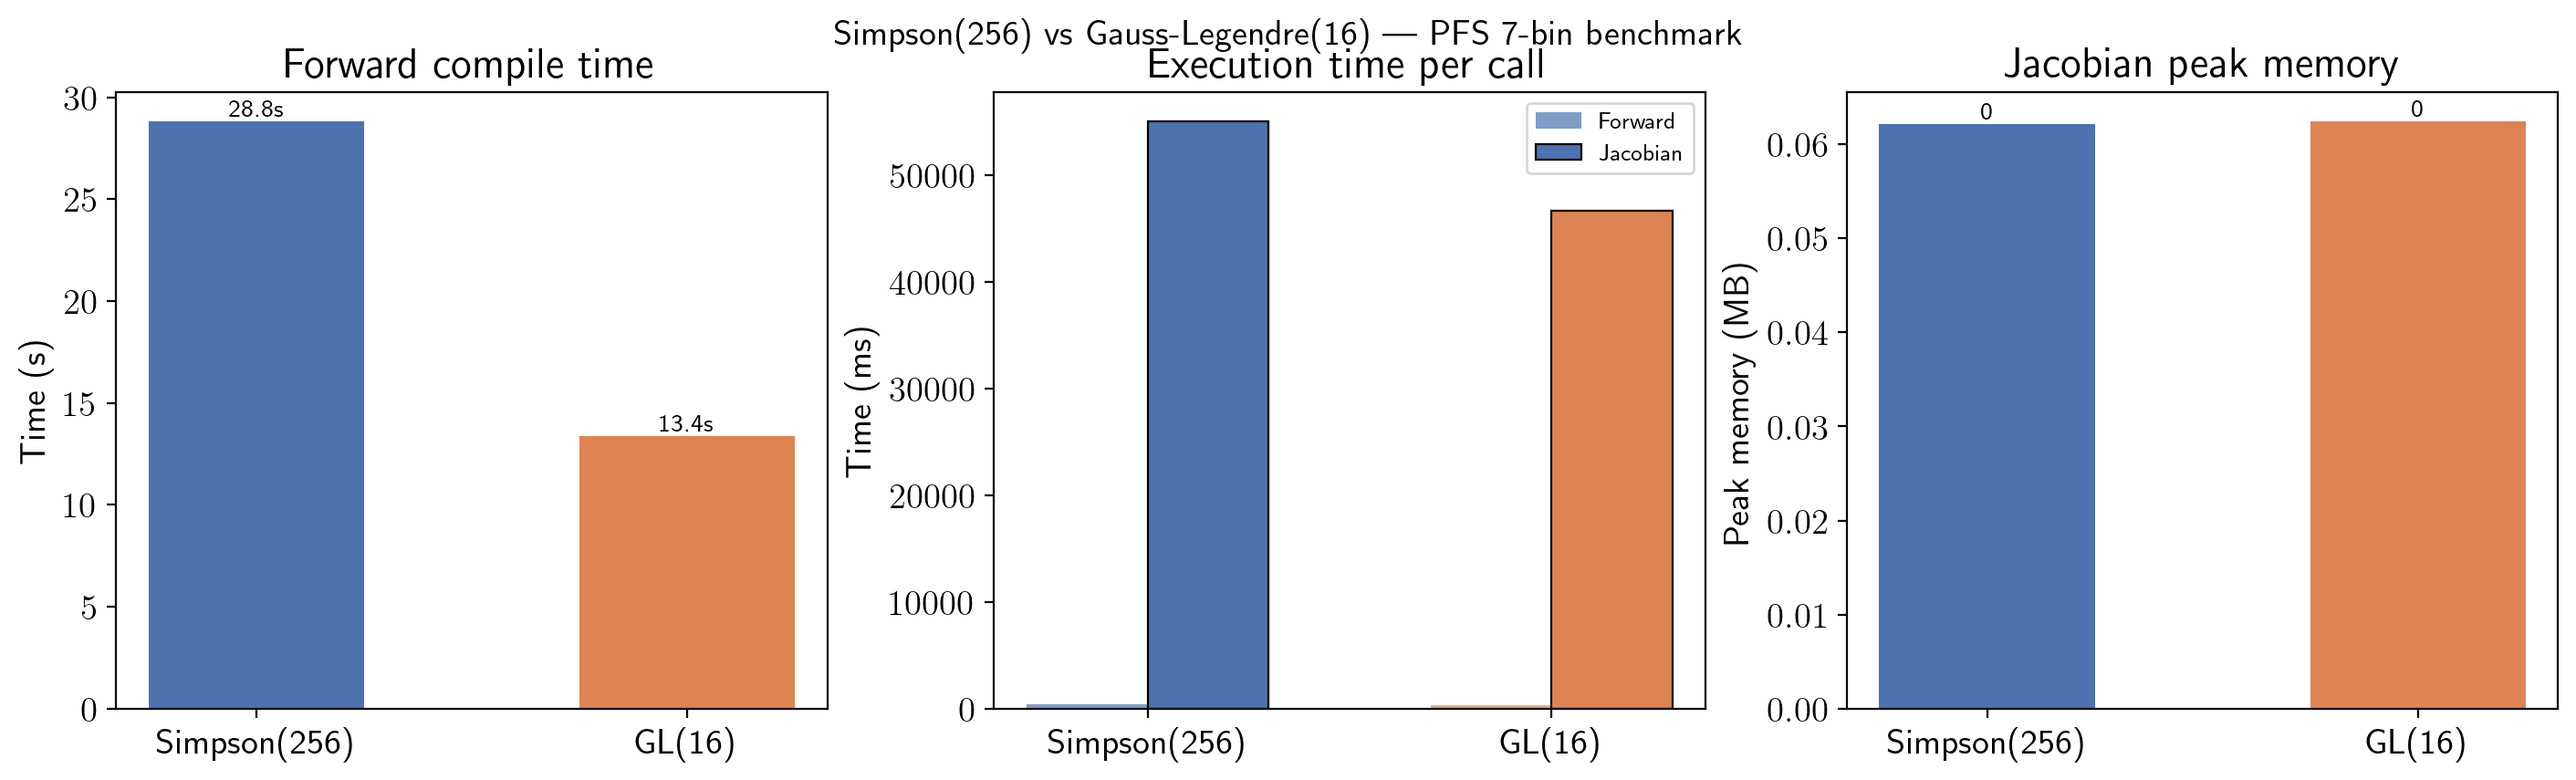

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4), constrained_layout=True)

labels = ['Simpson(256)', 'GL(16)']
bar_colors = ['#4C72B0', '#DD8452']
x = np.arange(2)

# Compilation time
ax = axes[0]
vals = [fwd_s_compile, fwd_g_compile]
bars = ax.bar(x, vals, color=bar_colors, width=0.5)
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylabel('Time (s)')
ax.set_title('Forward compile time')
for bar, v in zip(bars, vals):
    ax.text(bar.get_x() + bar.get_width()/2, v, f'{v:.1f}s',
            ha='center', va='bottom', fontsize=10)

# Execution time
ax = axes[1]
vals_fwd = [fwd_s_avg*1e3, fwd_g_avg*1e3]
vals_jac = [jac_s_avg*1e3, jac_g_avg*1e3]
w = 0.3
bars1 = ax.bar(x - w/2, vals_fwd, w, color=bar_colors, alpha=0.7, label='Forward')
bars2 = ax.bar(x + w/2, vals_jac, w, color=bar_colors, edgecolor='black', lw=0.8, label='Jacobian')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylabel('Time (ms)')
ax.set_title('Execution time per call')
ax.legend(fontsize=9)

# Memory
ax = axes[2]
vals = [mem_simpson, mem_gl]
bars = ax.bar(x, vals, color=bar_colors, width=0.5)
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylabel('Peak memory (MB)')
ax.set_title('Jacobian peak memory')
for bar, v in zip(bars, vals):
    ax.text(bar.get_x() + bar.get_width()/2, v, f'{v:.0f}',
            ha='center', va='bottom', fontsize=10)

fig.suptitle('Simpson(256) vs Gauss-Legendre(16) — PFS 7-bin benchmark',
             fontsize=14, y=1.03)